In [1]:
# open sep2012 run to investigate wvel rms

from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/run_iter24/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

prefix = 'diag_kpp'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)
ds['Zl'] = ds.Zl.astype(float)

In [3]:
ds.KPPviscA

<xarray.DataArray 'KPPviscA' (time: 70, Zl: 66, YC: 336, XC: 1128)> Size: 7GB
dask.array<concatenate, shape=(70, 66, 336, 1128), dtype=float32, chunksize=(1, 66, 336, 1128), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 560B 2012-09-02 2012-09-03 ... 2012-11-10
  * Zl       (Zl) float64 528B 0.0 -2.0 -4.0 -6.0 ... -4.5e+03 -5e+03 -5.5e+03
  * YC       (YC) float64 3kB -25.92 -25.75 -25.58 -25.42 ... 29.58 29.75 29.92
  * XC       (XC) float64 9kB 104.1 104.2 104.4 104.6 ... 291.6 291.8 291.9
    rA       (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    Depth    (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    dxF      (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    dyF      (YC, XC) >f4 2MB dask.array<chunksize=(336, 1128), meta=np.ndarray>
    iter     (time) int64 560B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:  KPPviscA
    long_name:      KPP vertical eddy viscosity coefficient
    units:          m^2/s

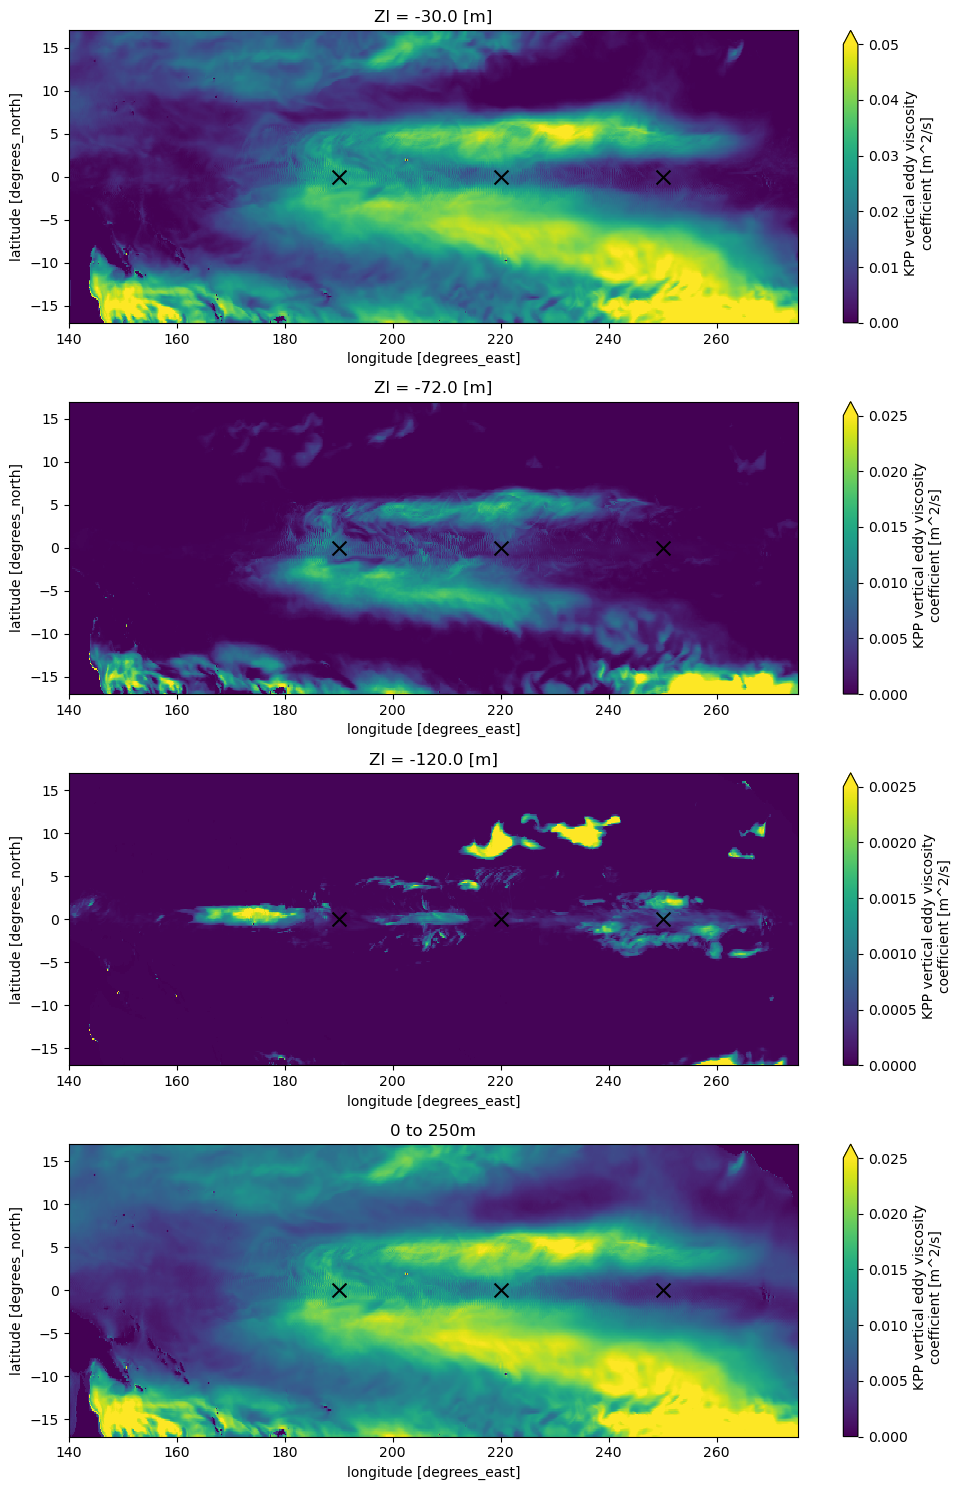

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,15),nrows=4)
wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=-30,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=0,vmax=0.05)
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=-70,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=-120,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=0,vmax=0.0025)
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=slice(0,-250))**2).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[3],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[3].scatter(lon,lat,color='k',marker='x',s=100)
ax[3].set_title("0 to 250m")

plt.tight_layout()
fig.savefig('assimilation_controls/shortwave_rad_xx/viscA_rms.png',dpi=300)

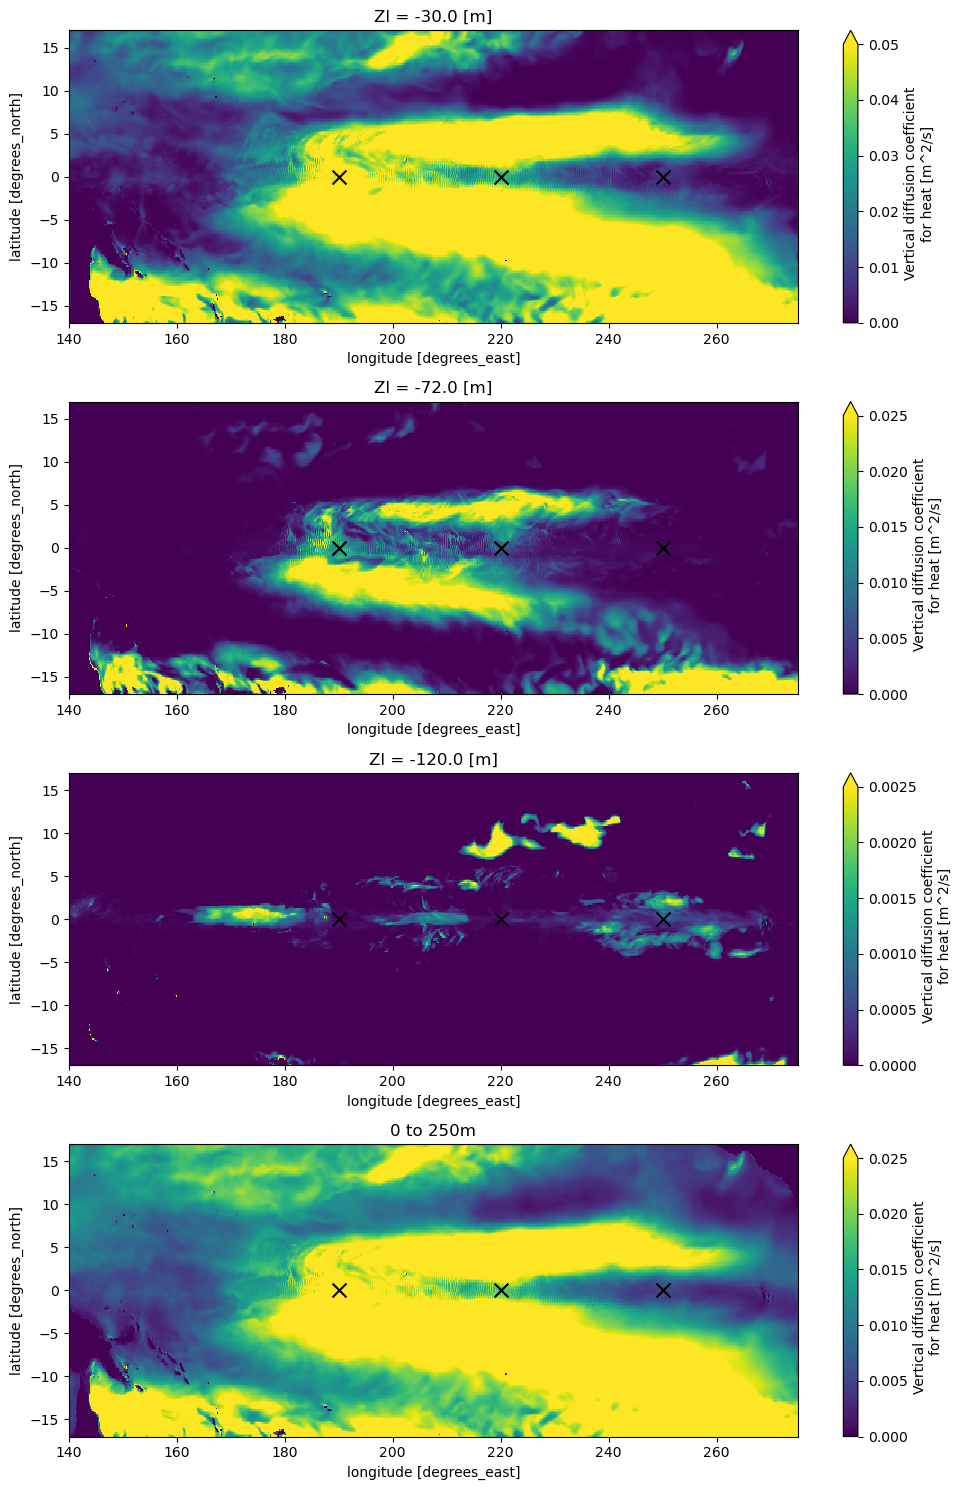

In [12]:

fig, ax = plt.subplots(figsize=(10,15),nrows=4)
wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=-30,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=0,vmax=0.05)
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=-70,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=-120,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=0,vmax=0.0025)
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=slice(0,-250))**2).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[3],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[3].scatter(lon,lat,color='k',marker='x',s=100)
ax[3].set_title("0 to 250m")

plt.tight_layout()
fig.savefig('assimilation_controls/shortwave_rad_xx/diffT_rms.png',dpi=300)

In [14]:
data_dir = '/data/SO6/TPOSE_diags/tpose6/sep2012/diags_iter7_daily/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

prefix = 'diag_kpp'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 48 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)
ds['Zl'] = ds.Zl.astype(float)

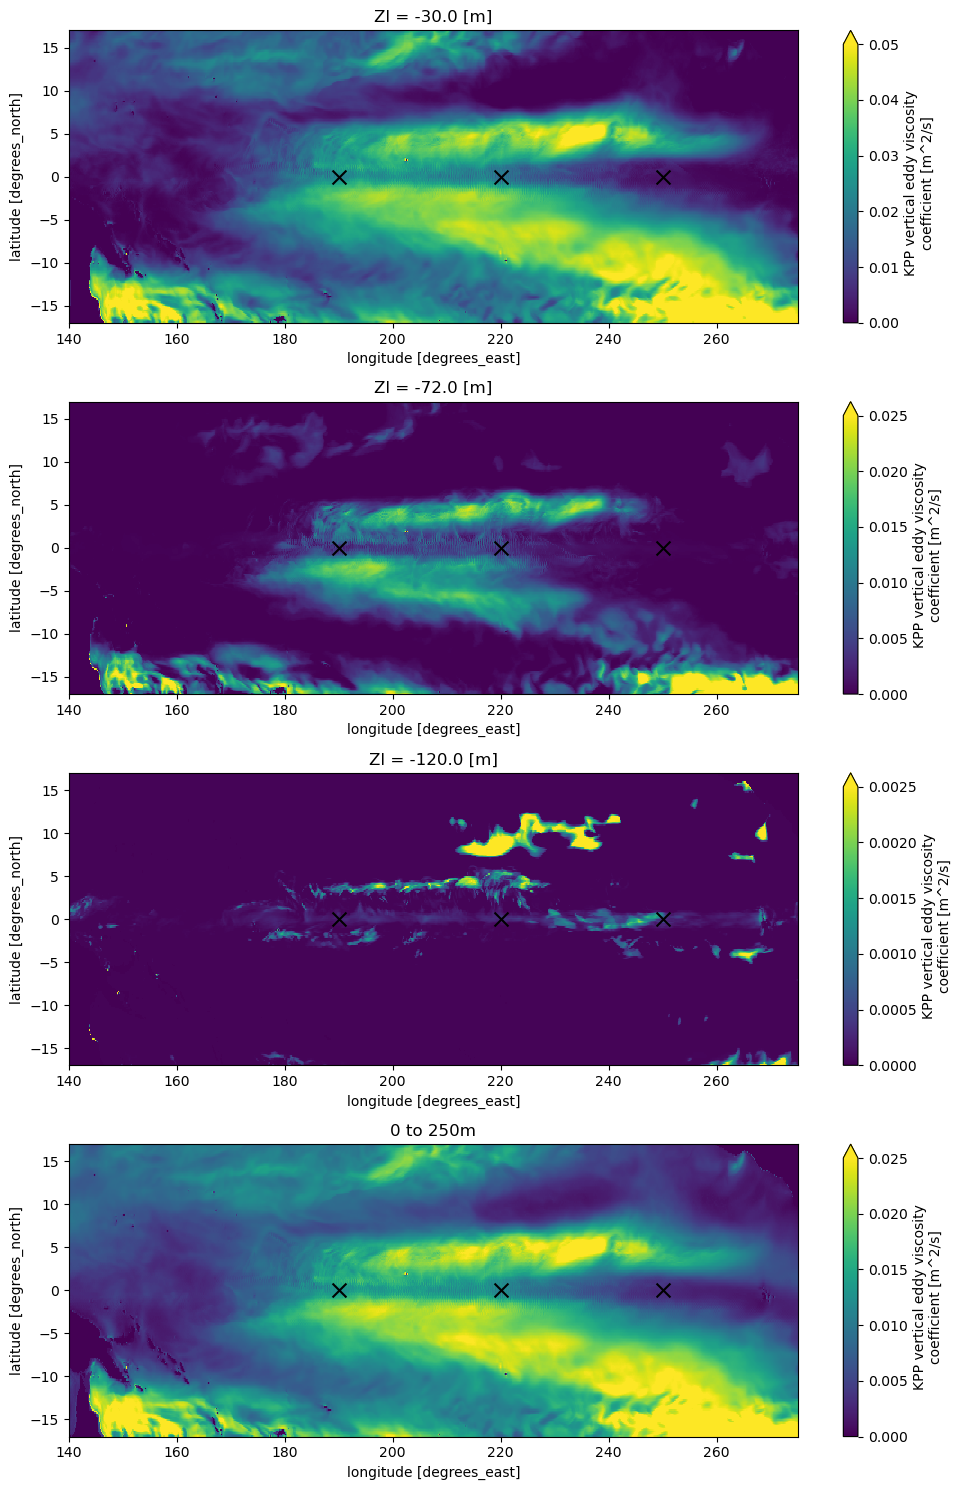

In [15]:
fig, ax = plt.subplots(figsize=(10,15),nrows=4)
wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=-30,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=0,vmax=0.05)
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=-70,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=-120,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=0,vmax=0.0025)
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPviscA.sel(Zl=slice(0,-250))**2).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[3],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[3].scatter(lon,lat,color='k',marker='x',s=100)
ax[3].set_title("0 to 250m")

plt.tight_layout()
fig.savefig('assimilation_controls/shortwave_rad_xx/viscA_rms_tpose_noVel.png',dpi=300)

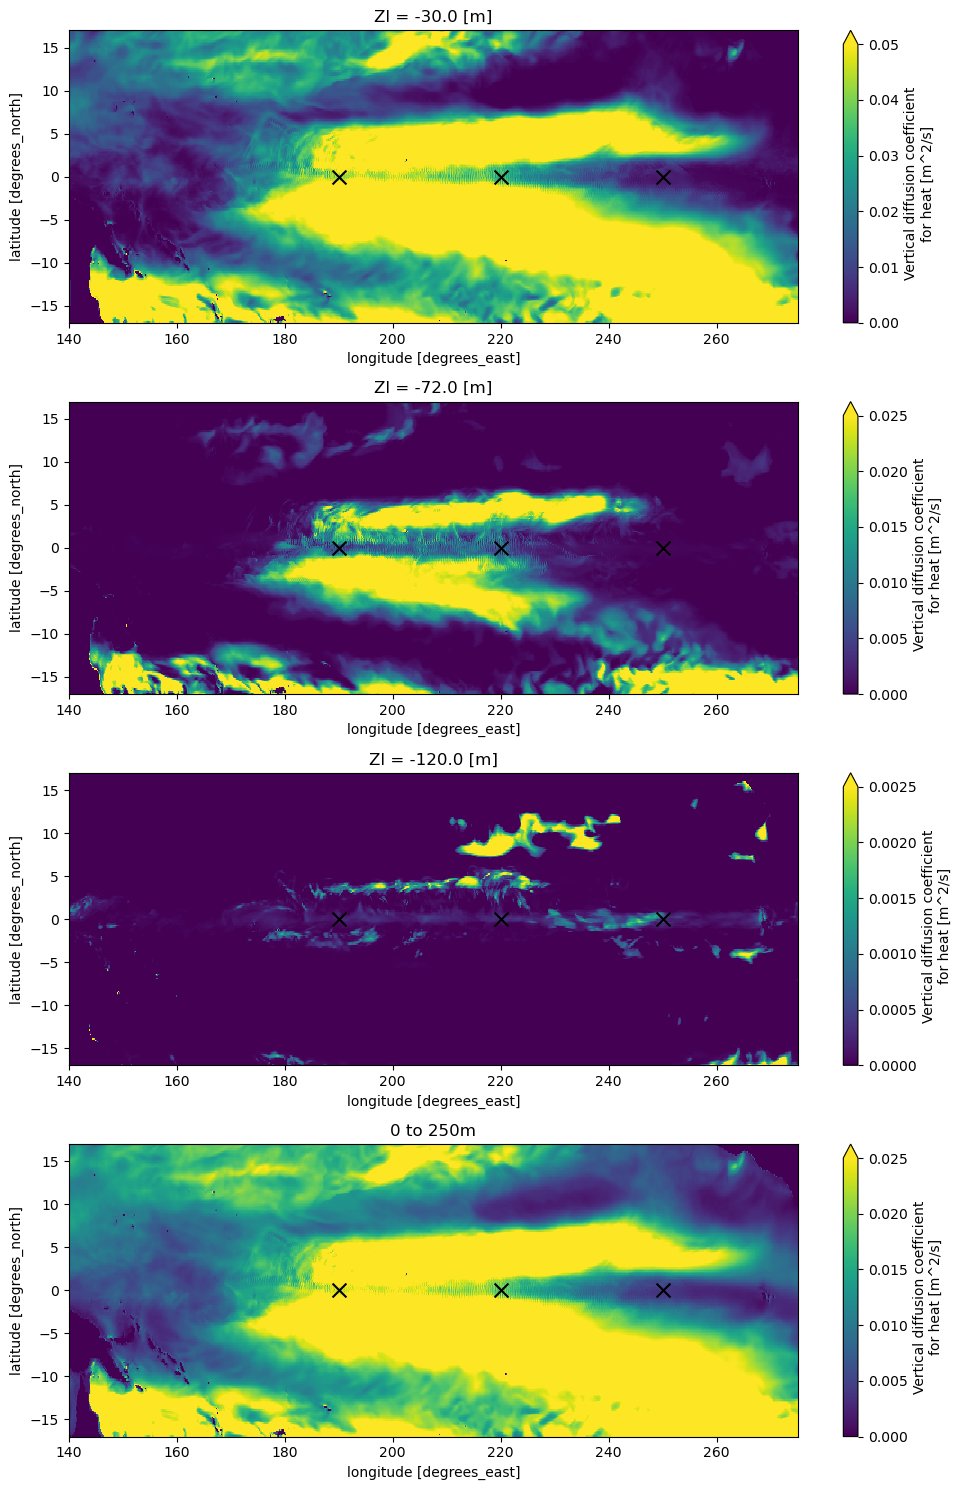

In [16]:

fig, ax = plt.subplots(figsize=(10,15),nrows=4)
wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=-30,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=0,vmax=0.05)
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=-70,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=-120,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=0,vmax=0.0025)
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.KPPdiffT.sel(Zl=slice(0,-250))**2).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[3],vmin=0,vmax=0.025)
for lat,lon in moorings:
    ax[3].scatter(lon,lat,color='k',marker='x',s=100)
ax[3].set_title("0 to 250m")

plt.tight_layout()
fig.savefig('assimilation_controls/shortwave_rad_xx/diffT_rms_tpose_noVel.png',dpi=300)